<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/ARIMA%20Liverpool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA Liverpool

#Librerías

In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 9.7 MB/s eta 0:00:00


In [2]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 10.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error
from tabulate import tabulate
import random
import os

In [4]:
# ─── Fijar TODAS las semillas al inicio del script ───
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
# ──────────────────────────────────────────────────────

#Liverpool

In [5]:
#Obtener datos
df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-26')

/tmp/ipykernel_904/2057216176.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-26')
[*********************100%***********************]  1 of 1 completed


In [6]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

In [7]:
#Para almacenar los datos por cualquier cosa
df.to_csv("GMEXICOB_historico.csv")

#Rendimientos

Vamos a usar los rendimientos logarítmicos para nuestros cálculos

In [8]:
#Obtener datos
precios = df['Close']

In [9]:
print(precios)

Date
2024-01-02    111.416779
2024-01-03    111.416779
2024-01-04    107.671677
2024-01-05    107.671677
2024-01-08    107.671677
                 ...    
2026-06-19    103.500000
2026-06-22    103.500000
2026-06-23    103.500000
2026-06-24    104.000000
2026-06-25    104.000000
Name: Close, Length: 621, dtype: float64


In [10]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
Name: Rendimientos_Log, Length: 621, dtype: float64


In [11]:
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
Name: Rendimientos_Log, Length: 620, dtype: float64


#ARIMA

In [12]:
#Nuestro parámetros son p=0, d=0 y q=0
#Aplicamos ARIMA con la función que ya trae Python

modelo0 = ARIMA(df['Rendimientos_Log'].dropna(), order=(0,0,0))
resultado0 = modelo0.fit()

print(resultado0.summary())


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  620
Model:                          ARIMA   Log Likelihood                1791.504
Date:                Tue, 06 Oct 2026   AIC                          -3579.009
Time:                        02:36:22   BIC                          -3570.149
Sample:                             0   HQIC                         -3575.565
                                - 620                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.001     -0.208      0.835      -0.001       0.001
sigma2         0.0002   2.22e-06     81.340      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.20   Jarque-

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [13]:
#Hacemos la prueba para saber si necesitamos utilizar GARCH o no
#Si p<0.5 si se requiere, si p>0.5 no se requiere

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['Rendimientos_Log'].dropna())

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 3.105934561661755
p-value: 0.9788199030871687


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


In [14]:
#Confirmaremos con Auto ARIMA que el modelo (0,0,0) es el mejor
Arima = auto_arima(df['Rendimientos_Log'])
print(Arima)

 ARIMA(0,0,0)(0,0,0)[0]          


In [55]:
#Hacemos prueba para saber si se requiere GARCH o no
residuos = resultado0.resid

for lag in [5,10,15,20]:
    lm, pvalue, _, _ = het_arch(residuos, nlags=lag)
    print(f"Lag={lag}: p-value={pvalue}")

Lag=5: p-value=0.9916004618506175
Lag=10: p-value=0.9778645860330285
Lag=15: p-value=0.9976615242299822
Lag=20: p-value=0.9997919905471261


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


#Prueba con datos de entrenamiento

In [18]:
#Vamos a ver cuáles son los precios reales de los últimos 100 días
precios_reales = precios[-100:]
print(precios_reales)

Date
2026-01-29    100.283028
2026-01-30    102.839256
2026-02-03    102.839256
2026-02-04    102.858925
2026-02-05    102.858925
                 ...    
2026-06-19    103.500000
2026-06-22    103.500000
2026-06-23    103.500000
2026-06-24    104.000000
2026-06-25    104.000000
Name: Close, Length: 100, dtype: float64


In [19]:
rendimientos = df['Rendimientos_Log'].dropna()  # ← eliminar NaN

train_rend = df['Rendimientos_Log'][:-100]
test_rend  = df['Rendimientos_Log'][-100:]

In [20]:
# Alinear y ajustar
full_range = pd.date_range(train_rend.index.min(), train_rend.index.max(), freq='B')
train_aligned = train_rend.reindex(full_range).fillna(0)

In [21]:
# ARIMA
modelo = ARIMA(train_aligned, order=(0, 0, 1), freq='B')
resultado = modelo.fit()
pred = resultado.forecast(steps=len(test_rend))

In [22]:
ultimo_precio = precios.iloc[-101]

pprecios_pred = []
precio_actual= ultimo_precio

for r in pred:
    precio_actual = precio_actual * np.exp(r)
    pprecios_pred.append(precio_actual)

In [23]:
comparacion = pd.DataFrame({
    "Real": precios_reales,
    "Pronosticado": pprecios_pred
})

print(comparacion)

                  Real  Pronosticado
Date                                
2026-01-29  100.283028    100.227356
2026-01-30  102.839256    100.207414
2026-02-03  102.839256    100.187475
2026-02-04  102.858925    100.167540
2026-02-05  102.858925    100.147609
...                ...           ...
2026-06-19  103.500000     98.350398
2026-06-22  103.500000     98.330829
2026-06-23  103.500000     98.311263
2026-06-24  104.000000     98.291702
2026-06-25  104.000000     98.272144

[100 rows x 2 columns]


In [24]:
#Imprimir resultados de los 100 días
print(comparacion.to_string())

                  Real  Pronosticado
Date                                
2026-01-29  100.283028    100.227356
2026-01-30  102.839256    100.207414
2026-02-03  102.839256    100.187475
2026-02-04  102.858925    100.167540
2026-02-05  102.858925    100.147609
2026-02-06  102.858925    100.127682
2026-02-09  102.052734    100.107759
2026-02-10  100.292862    100.087840
2026-02-11  104.215698    100.067925
2026-02-12  104.215698    100.048014
2026-02-13  104.215698    100.028107
2026-02-16  102.052734    100.008203
2026-02-17  102.052734     99.988304
2026-02-18  102.052734     99.968409
2026-02-19  102.052734     99.948518
2026-02-20  102.052734     99.928630
2026-02-23  102.052734     99.908747
2026-02-24  102.052734     99.888868
2026-02-25  106.083717     99.868992
2026-02-26  106.083717     99.849121
2026-02-27  106.083717     99.829253
2026-03-02  106.083717     99.809390
2026-03-03  106.083717     99.789530
2026-03-04  106.083717     99.769674
2026-03-05  106.083717     99.749822
2

In [25]:
train = precios[:-100]
test = precios[-100:]

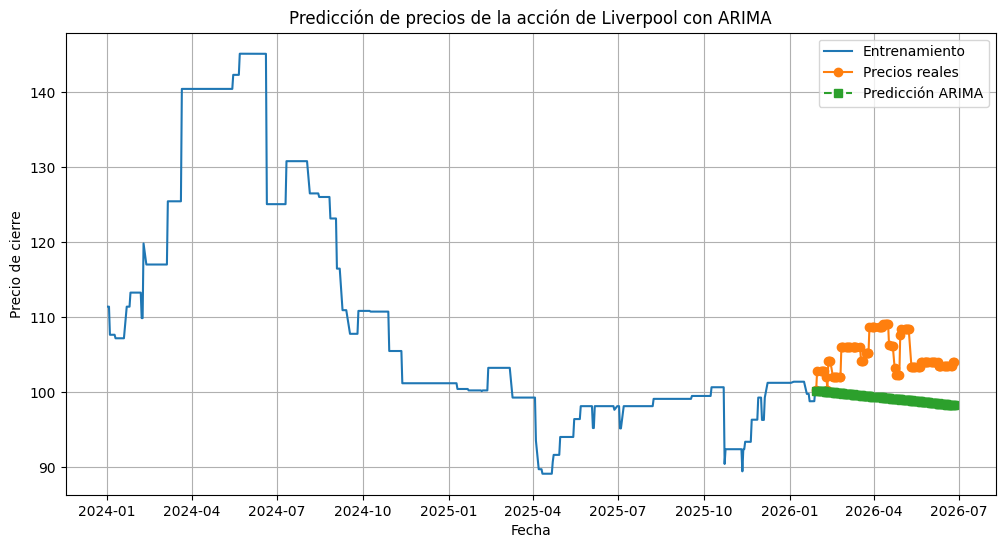

In [26]:
plt.figure(figsize=(12,6))

# Datos de entrenamiento
plt.plot(train.index, train,
         label='Entrenamiento')

# Datos reales
plt.plot(test.index, test,
         marker='o', label='Precios reales')

# Predicción
plt.plot(test.index, pprecios_pred,
         marker='s', linestyle='--',
         label='Predicción ARIMA')

plt.title('Predicción de precios de la acción de Liverpool con ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.legend()
plt.grid(True)

plt.show()

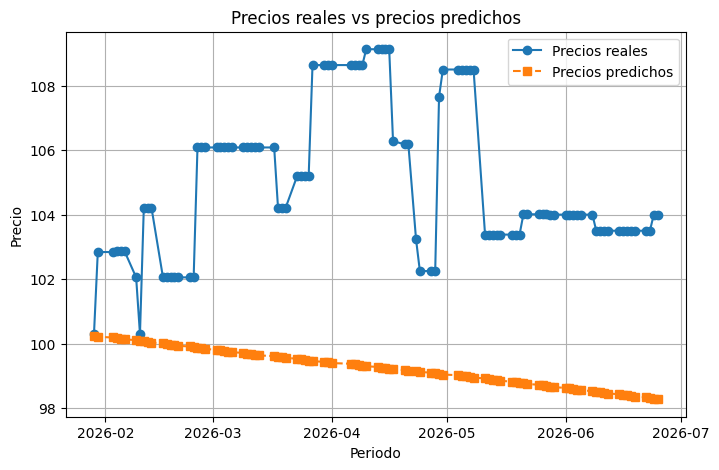

In [27]:
plt.figure(figsize=(8,5))

plt.plot(precios_reales.index, precios_reales,
         marker='o', label='Precios reales')

plt.plot(precios_reales.index, pprecios_pred,
         marker='s', linestyle='--', label='Precios predichos')

plt.title('Precios reales vs precios predichos')
plt.xlabel('Periodo')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()

##Estadísticos de Bondad de Ajuste

###Error Cuadrático Medio (MAE)

In [28]:
mae = mean_absolute_error(precios_reales, pprecios_pred)
print(f"MAE = {mae: .2f}")

MAE =  5.66


In [29]:
mae_porcentaje = (mae /precios_reales.mean()) * 100
print(f"% MAE ARIMA: {mae_porcentaje:.4f} %")

% MAE ARIMA: 5.3910 %


###Error Cuadrático Medio (RMSE)

In [30]:
rmse = np.sqrt(mean_squared_error(precios_reales, pprecios_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 6.13


In [31]:
rmse_porcentaje = (rmse / precios_reales.mean()) * 100
print(f"% RMSE ARIMA: {rmse_porcentaje:.4f} %")

% RMSE ARIMA: 5.8412 %


###Error Porcentual Absoluto Medio (MAPE)

In [32]:
mape = mean_absolute_percentage_error(precios_reales, pprecios_pred) * 100
print(f"MAPE ARIMA= {mape: .4f} %")

MAPE ARIMA=  5.3465 %


#Predicción de Precio del día siguiente (29/06/26)


In [33]:
#Alineamos la serie original con frecuencia de días hábiles ('B') para corregir el índice temporal
rendimientos_con_freq = df['Rendimientos_Log'].dropna().asfreq('B', method='bfill')

In [34]:
#Reajustamos el modelo ARIMA con los datos alineados
modelo_temp = ARIMA(rendimientos_con_freq, order=(0,0,1))
resultado_temp = modelo_temp.fit()

In [35]:
#Realizamos el pronóstico sin problemas de índices
prediction = resultado_temp.forecast(steps=1)
print(prediction)

2026-06-26   -0.000199
Freq: B, dtype: float64


In [36]:
#Vamos a convertir los rendimientos en precios
ultimo_precio = precios.iloc[-1]   # Último precio conocido

precio_pred = []
precio_actual = ultimo_precio

for r in prediction:
    precio_actual = precio_actual * np.exp(r)
    precio_pred.append(precio_actual)

In [37]:
#Prediccion precio del siguiente día de cotizacion (29/06/26)
#Al imprimir aparece la fecha del 26, pero la fecha que se predijo es la del 29/06/2026
precio_pred = pd.Series(precio_pred, index=prediction.index)

print(precio_pred)

2026-06-26    103.979279
Freq: B, dtype: float64


####Hacer comparación día siguiente

In [38]:
#Vamos a extraer el ultimo precio, el del día 29-06-26
#Obtener datos
hoy = yf.download('LIVEPOL1.MX', start='2026-06-29', end ='2026-06-30')

/tmp/ipykernel_904/4114429200.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hoy = yf.download('LIVEPOL1.MX', start='2026-06-29', end ='2026-06-30')
[*********************100%***********************]  1 of 1 completed


In [39]:
# Eliminar nivel del ticker
hoy.columns = hoy.columns.droplevel(1)

In [40]:
Precio_hoy = hoy['Close']
print(Precio_hoy)

Date
2026-06-29    104.0
Name: Close, dtype: float64


In [41]:
#Para almacenar los datos por cualquier cosa
hoy.to_csv("GMEXICOB_29_06_26.csv")

In [42]:
comparacion1 = pd.DataFrame({
    "Real": Precio_hoy,
    "Pronosticado": precio_pred
})

print(comparacion1)

             Real  Pronosticado
2026-06-26    NaN    103.979279
2026-06-29  104.0           NaN


##Estadísticos Bonda de Ajuste

###Error Cuadrático Medio (MAE)

In [43]:
mae = mean_absolute_error(hoy['Close'], precio_pred)
print(f"MAE = {mae: .2f}")

MAE =  0.02


In [44]:
mae_porcentaje = (mae / Precio_hoy) * 100
print(f"% MAE ARIMA: {mae_porcentaje.iloc[0]:.4f} %")

% MAE ARIMA: 0.0199 %


###Error Cuadrático Medio (RMSE)

In [45]:
rmse = np.sqrt(mean_squared_error(hoy['Close'], precio_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 0.02


In [46]:
rmse_porcentaje = (rmse / Precio_hoy) * 100
print(f"% RMSE ARIMA: {rmse_porcentaje.iloc[0]:.4f} %")

% RMSE ARIMA: 0.0199 %


###Error Porcentual Absoluto Medio (MAPE)

In [47]:
mape = mean_absolute_percentage_error(hoy['Close'], precio_pred) * 100
print(f"MAPE = {mape: .4f} %")

MAPE =  0.0199 %


#Predicción para 100 días desde el 29/06/26

In [48]:
# Ajustamos el modelo con los rendimientos que sí tienen frecuencia temporal ('B') y realizamos el pronóstico
modelo_freq = ARIMA(rendimientos_con_freq, order=(0, 0, 1))
resultado_freq = modelo_freq.fit()

predictions = resultado_freq.forecast(steps=100)

In [49]:
ultimo_precio = precios.iloc[-1]

precios_pred = []
precio_actual = ultimo_precio

for r in predictions:
    precio_actual = precio_actual * np.exp(r)
    precios_pred.append(precio_actual)

In [50]:
fechas_pred = pd.date_range(
    start='2026-06-29',
    periods=100,
    freq='B' #Porque trabajamos con precios de la BMV
)

In [51]:
print(fechas_pred)
print(precios_pred)

DatetimeIndex(['2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02',
               '2026-07-03', '2026-07-06', '2026-07-07', '2026-07-08',
               '2026-07-09', '2026-07-10', '2026-07-13', '2026-07-14',
               '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-20',
               '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24',
               '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30',
               '2026-07-31', '2026-08-03', '2026-08-04', '2026-08-05',
               '2026-08-06', '2026-08-07', '2026-08-10', '2026-08-11',
               '2026-08-12', '2026-08-13', '2026-08-14', '2026-08-17',
               '2026-08-18', '2026-08-19', '2026-08-20', '2026-08-21',
               '2026-08-24', '2026-08-25', '2026-08-26', '2026-08-27',
               '2026-08-28', '2026-08-31', '2026-09-01', '2026-09-02',
               '2026-09-03', '2026-09-04', '2026-09-07', '2026-09-08',
               '2026-09-09', '2026-09-10', '2026-09-11', '2026-09-14',
      

In [52]:
pronosticos = pd.DataFrame({
    "Fecha": fechas_pred,
    "Precio pronosticado": precios_pred
})

print(pronosticos)

        Fecha  Precio pronosticado
0  2026-06-29           103.979279
1  2026-06-30           103.958658
2  2026-07-01           103.938041
3  2026-07-02           103.917428
4  2026-07-03           103.896819
..        ...                  ...
95 2026-11-09           102.038425
96 2026-11-10           102.018189
97 2026-11-11           101.997957
98 2026-11-12           101.977728
99 2026-11-13           101.957504

[100 rows x 2 columns]


In [53]:
print(pronosticos.to_string())

        Fecha  Precio pronosticado
0  2026-06-29           103.979279
1  2026-06-30           103.958658
2  2026-07-01           103.938041
3  2026-07-02           103.917428
4  2026-07-03           103.896819
5  2026-07-06           103.876215
6  2026-07-07           103.855614
7  2026-07-08           103.835018
8  2026-07-09           103.814425
9  2026-07-10           103.793837
10 2026-07-13           103.773252
11 2026-07-14           103.752672
12 2026-07-15           103.732096
13 2026-07-16           103.711524
14 2026-07-17           103.690956
15 2026-07-20           103.670392
16 2026-07-21           103.649832
17 2026-07-22           103.629277
18 2026-07-23           103.608725
19 2026-07-24           103.588177
20 2026-07-27           103.567634
21 2026-07-28           103.547094
22 2026-07-29           103.526559
23 2026-07-30           103.506028
24 2026-07-31           103.485500
25 2026-08-03           103.464977
26 2026-08-04           103.444458
27 2026-08-05       

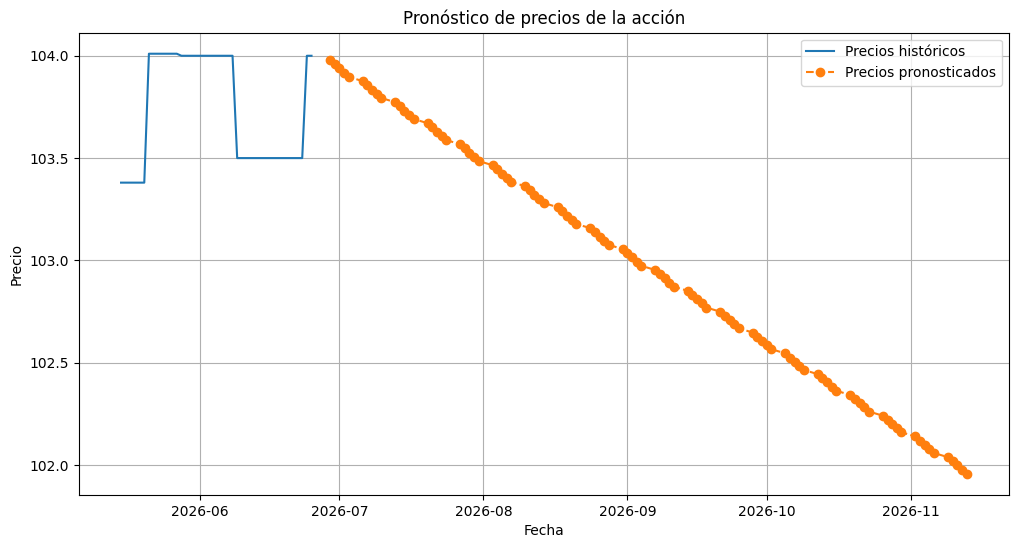

In [54]:
plt.figure(figsize=(12,6))

# Últimos precios históricos
plt.plot(precios.index[-30:], precios[-30:], label='Precios históricos')

# Predicciones
plt.plot(fechas_pred, precios_pred,
         marker='o',
         linestyle='--',
         label='Precios pronosticados')

plt.title('Pronóstico de precios de la acción')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()